# PriorityPulse — Exploratory Data Analysis

End-to-end walkthrough of the data pipeline:

1. **Raw TWCS dataset** — ~2.8M tweets, all companies
2. **Cleaned dataset** — filtering funnel, airline selection, agent response join
3. **Labels & scoring** — URGENT vs NORMAL weak supervision
4. **ML features** — 14 engineered signals used by the classifiers
5. **Model training results** — 60/20/20 split, three models, val vs test


In [29]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})

URGENT_COLOR  = '#ef4444'
NORMAL_COLOR  = '#3b82f6'
ACCENT_COLOR  = '#8b5cf6'
NEUTRAL_COLOR = '#64748b'
print('Libraries loaded.')


Libraries loaded.


In [30]:
ROOT       = Path('..').resolve()          # priority-pulse/
DATA_RAW   = ROOT / 'data' / 'raw'
DATA_PROC  = ROOT / 'data' / 'processed'
MODELS_DIR = ROOT / 'models'

paths = {
    'raw':     DATA_RAW  / 'twcs.csv',
    'cleaned': DATA_PROC / 'cleaned_tickets.csv',
    'labeled': DATA_PROC / 'labeled_tickets.csv',
    'ml':      DATA_PROC / 'ml_features.csv',
    'metrics': MODELS_DIR / 'metrics.json',
    'stats':   DATA_PROC / 'pipeline_stats.json',
}
for name, p in paths.items():
    status = 'OK     ' if p.exists() else 'MISSING (run pipeline first)'
    print(f'  {status}  {name:10s}  {p.relative_to(ROOT)}')


  OK       raw         data\raw\twcs.csv
  OK       cleaned     data\processed\cleaned_tickets.csv
  OK       labeled     data\processed\labeled_tickets.csv
  OK       ml          data\processed\ml_features.csv
  OK       metrics     models\metrics.json
  OK       stats       data\processed\pipeline_stats.json


---
## 1 · Raw TWCS Dataset

The Twitter Customer Support Corpus from Kaggle — real customer-brand interactions,
both inbound (customer) and outbound (agent) across many companies.


In [61]:
df_raw = pd.read_csv(paths['raw'])
print(f'Loaded {len(df_raw):,}')
print(f'Columns: {df_raw.columns.tolist()}')
print('\nDtypes:')
print(df_raw.dtypes)


Loaded 2,811,774
Columns: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']

Dtypes:
tweet_id                     int64
author_id                      str
inbound                       bool
created_at                     str
text                           str
response_tweet_id              str
in_response_to_tweet_id    float64
dtype: object


In [32]:
df_raw.head(5)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [33]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
print('Missing values:')
print(pd.DataFrame({'count': missing, 'pct%': missing_pct}).query('count > 0'))


Missing values:
                         count  pct%
response_tweet_id        99370  33.1
in_response_to_tweet_id  76918  25.6


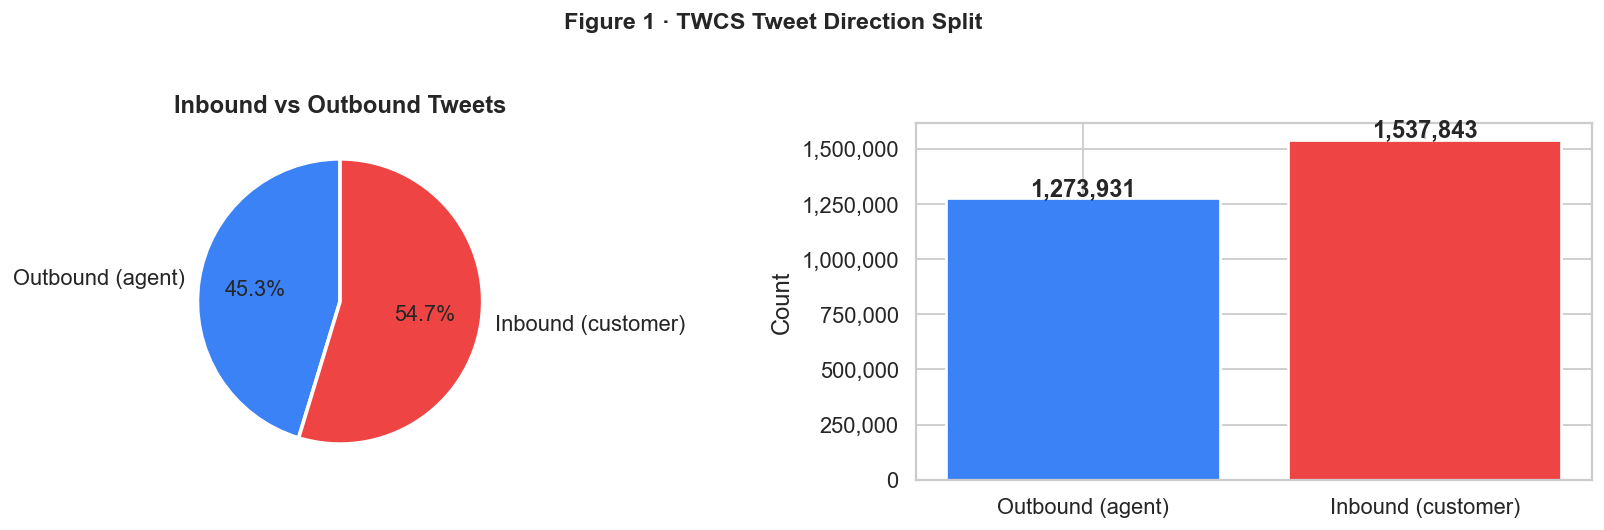

Inbound:  1,537,843  (54.7%)
Outbound: 1,273,931  (45.3%)


In [62]:
# Figure 1: Inbound vs Outbound
inbound_counts = df_raw['inbound'].value_counts()
sizes  = [inbound_counts.get(False, 0), inbound_counts.get(True, 0)]
labels = ['Outbound (agent)', 'Inbound (customer)']
colors = [NORMAL_COLOR, URGENT_COLOR]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=colors, autopct='%1.1f%%',
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts: at.set_fontsize(12)
axes[0].set_title('Inbound vs Outbound Tweets', fontweight='bold')

bars = axes[1].bar(labels, sizes, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, sizes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(sizes)*0.01,
                 f'{val:,}', ha='center', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Figure 1 · TWCS Tweet Direction Split', y=1.02, fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
print(f'Inbound:  {sizes[1]:,}  ({100*sizes[1]/sum(sizes):.1f}%)')
print(f'Outbound: {sizes[0]:,}  ({100*sizes[0]/sum(sizes):.1f}%)')


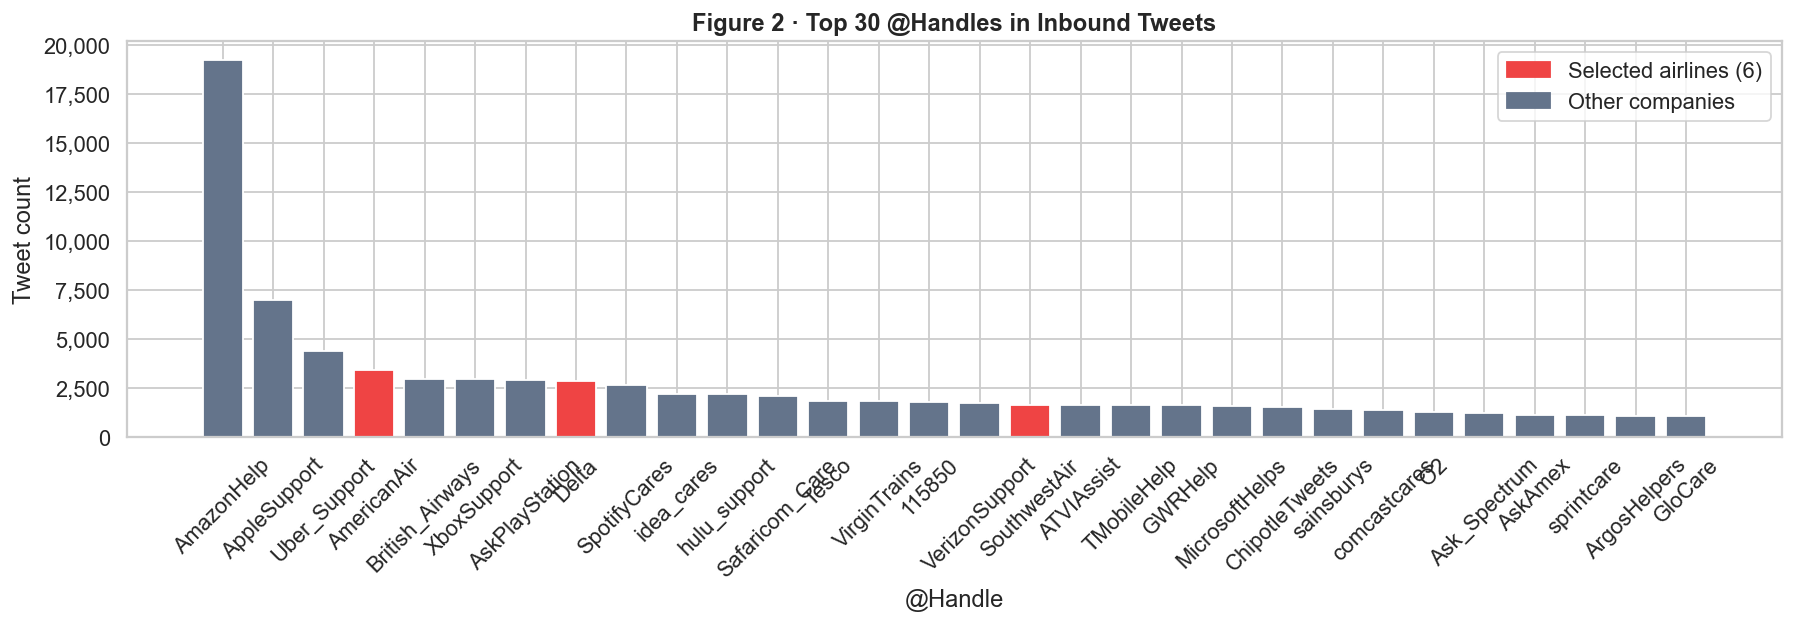

In [35]:
# Figure 2: Top 30 @handles in inbound tweets
df_inbound = df_raw[df_raw['inbound'] == True].copy()
df_inbound['first_mention'] = df_inbound['text'].str.extract(r'^@([A-Za-z0-9_]+)', expand=False)
top_mentions = df_inbound['first_mention'].value_counts().head(30)

TARGET_AIRLINES = {'americanair', 'delta', 'southwestair', 'jetblue', 'united', 'usairways'}
bar_colors = [URGENT_COLOR if str(h).lower() in TARGET_AIRLINES else NEUTRAL_COLOR
              for h in top_mentions.index]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(top_mentions.index, top_mentions.values, color=bar_colors, edgecolor='white')
ax.set_xlabel('@Handle')
ax.set_ylabel('Tweet count')
ax.set_title('Figure 2 · Top 30 @Handles in Inbound Tweets', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
selected_patch = mpatches.Patch(color=URGENT_COLOR, label='Selected airlines (6)')
other_patch    = mpatches.Patch(color=NEUTRAL_COLOR, label='Other companies')
ax.legend(handles=[selected_patch, other_patch])
plt.tight_layout()
plt.show()


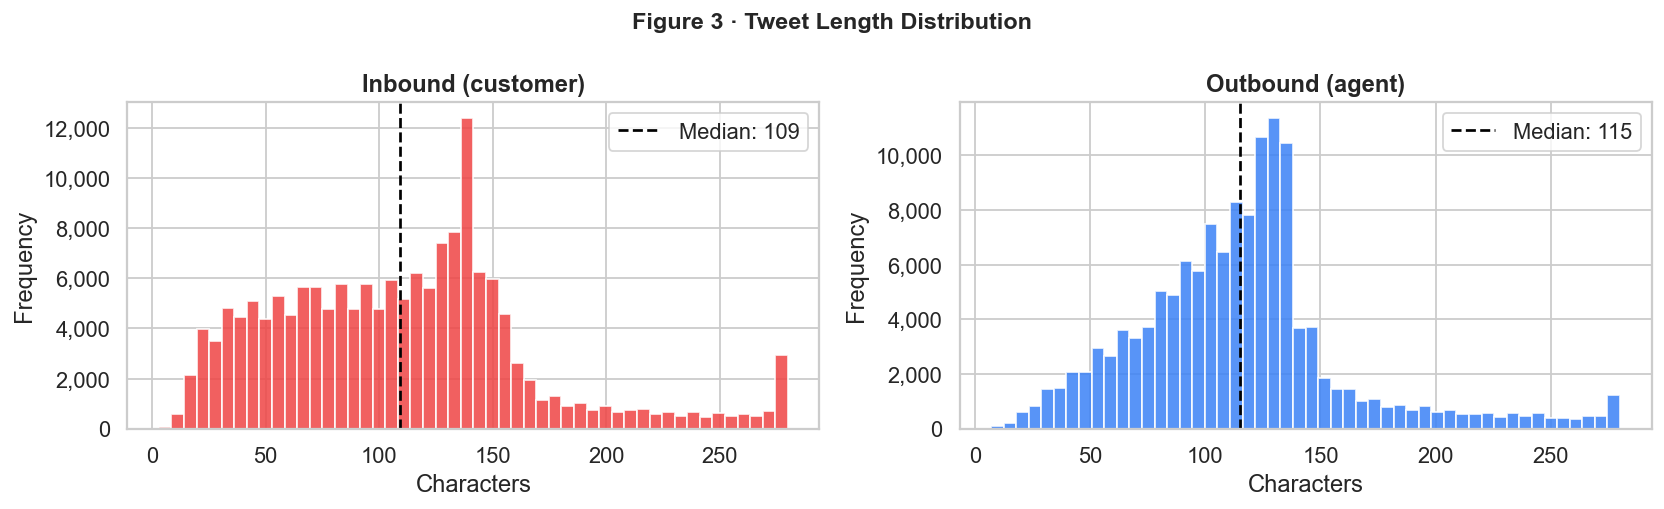

Inbound  — mean: 110  median: 109  max: 513
Outbound — mean: 116  median: 115  max: 338


In [36]:
# Figure 3: Text length distribution
df_raw['text_len'] = df_raw['text'].str.len()
df_in  = df_raw[df_raw['inbound'] == True]['text_len']
df_out = df_raw[df_raw['inbound'] != True]['text_len']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, data, label, color in [
    (axes[0], df_in,  'Inbound (customer)', URGENT_COLOR),
    (axes[1], df_out, 'Outbound (agent)',   NORMAL_COLOR),
]:
    ax.hist(data.clip(upper=280), bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.0f}')
    ax.set_xlabel('Characters')
    ax.set_ylabel('Frequency')
    ax.set_title(label, fontweight='bold')
    ax.legend()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.suptitle('Figure 3 · Tweet Length Distribution', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
print(f'Inbound  — mean: {df_in.mean():.0f}  median: {df_in.median():.0f}  max: {df_in.max()}')
print(f'Outbound — mean: {df_out.mean():.0f}  median: {df_out.median():.0f}  max: {df_out.max()}')


---
## 2 · Cleaning Pipeline

From ~2.8M raw tweets to ~87,848 clean customer tickets.
Three stages: direction filter → airline filter → quality cleaning.


In [37]:
df_clean = pd.read_csv(paths['cleaned'])
print(f'Cleaned dataset: {len(df_clean):,} rows')
print(f'Columns: {df_clean.columns.tolist()}')
df_clean.head(3)


Cleaned dataset: 87,848 rows
Columns: ['tweet_id', 'customer_id', 'airline', 'created_at', 'inbound', 'original_text', 'text', 'agent_response']


,tweet_id,customer_id,airline,created_at,inbound,original_text,text,agent_response
0,611,115818,DELTA,Sat Aug 06 01:31:50 +0000 2016,True,@DELTA i booked my flight using delta amex car...,i booked my flight using delta amex card. Chec...,"Glad to check. Pls, DM your confirmation numbe..."
1,791,115882,Delta,Tue Oct 31 22:33:11 +0000 2017,True,@Delta I checked daily and flight 1403 was nev...,I checked daily and flight 1403 was never offe...,My apologies. If that flight never showed up o...
2,792,115882,Delta,Tue Oct 31 21:33:48 +0000 2017,True,@Delta why wasn't earlier flight offered when ...,why wasn't earlier flight offered when I tried...,I'm sorry. The earlier flight may not have bee...


In [38]:
if paths['stats'].exists():
    with open(paths['stats']) as f:
        stats = json.load(f)
    raw_total    = stats.get('raw_total',            2_811_774)
    raw_inbound  = stats.get('raw_inbound_count',    1_382_038)
    after_filter = stats.get('after_airline_filter',    91_744)
    rem_empty    = stats.get('removed_empty',              630)
    rem_low      = stats.get('removed_low_quality',      2_260)
    rem_dupe     = stats.get('removed_duplicates',        1_006)
    final_count  = stats.get('final_count',             87_848)
    with_resp    = stats.get('with_agent_response',     64_919)
    resp_pct     = stats.get('agent_response_pct',        73.9)
    print('Stats loaded from pipeline_stats.json')
else:
    raw_total=2_811_774; raw_inbound=1_382_038; after_filter=91_744
    rem_empty=630; rem_low=2_260; rem_dupe=1_006
    final_count = len(df_clean)
    with_resp = (df_clean['agent_response'].str.len() > 0).sum() \
                if 'agent_response' in df_clean.columns else 64_919
    resp_pct = round(100 * with_resp / final_count, 1)
    print('Stats derived from fallback values (pipeline_stats.json not found)')

print(f'Funnel: {raw_total:,} -> {raw_inbound:,} -> {after_filter:,} -> {final_count:,}')


Stats loaded from pipeline_stats.json
Funnel: 2,811,774 -> 1,537,843 -> 91,744 -> 87,848


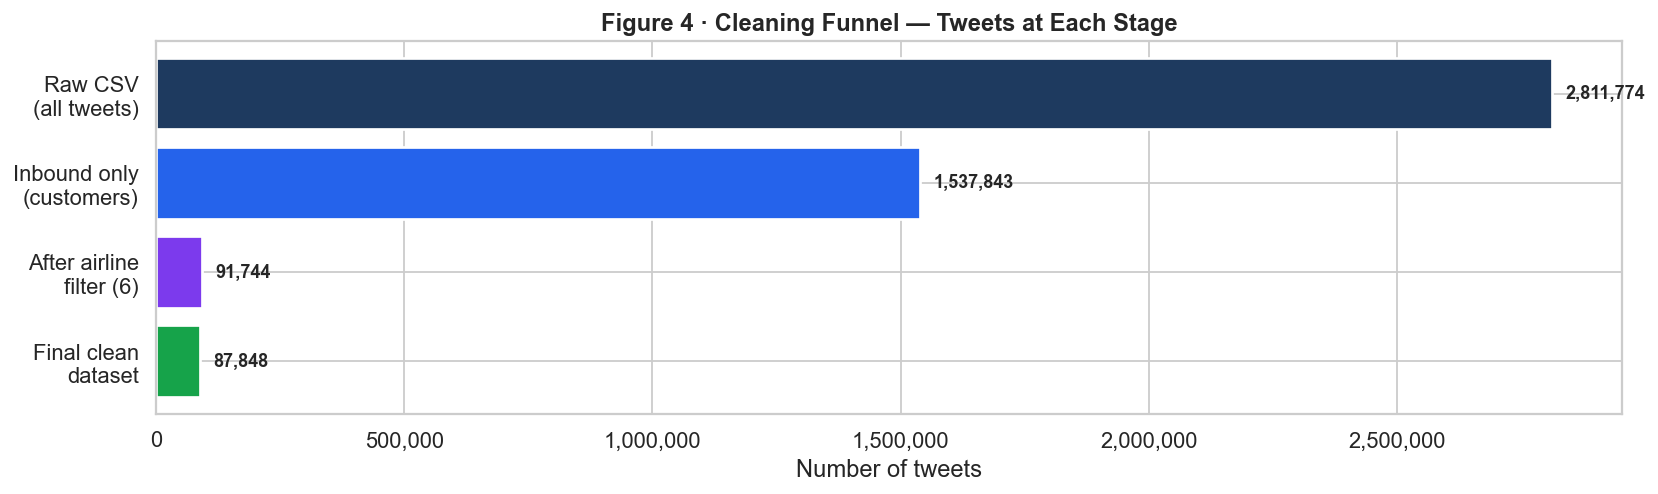

Retention: 3.12% of raw data kept
Quality removals: 630 empty + 2260 low-quality + 1006 duplicates = 3,896


In [39]:
# Figure 4: Cleaning funnel
stages = [
    ('Raw CSV\n(all tweets)',           raw_total),
    ('Inbound only\n(customers)',       raw_inbound),
    ('After airline\nfilter (6)',       after_filter),
    ('Final clean\ndataset',           final_count),
]
labels_f = [s[0] for s in stages]
values_f = [s[1] for s in stages]
colors_f = ['#1e3a5f', '#2563eb', '#7c3aed', '#16a34a']

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.barh(labels_f, values_f, color=colors_f, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values_f):
    ax.text(val + max(values_f)*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontweight='bold', fontsize=10)
ax.set_xlabel('Number of tweets')
ax.set_title('Figure 4 · Cleaning Funnel — Tweets at Each Stage', fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(f'Retention: {100*final_count/raw_total:.2f}% of raw data kept')
print(f'Quality removals: {rem_empty} empty + {rem_low} low-quality + {rem_dupe} duplicates = {rem_empty+rem_low+rem_dupe:,}')


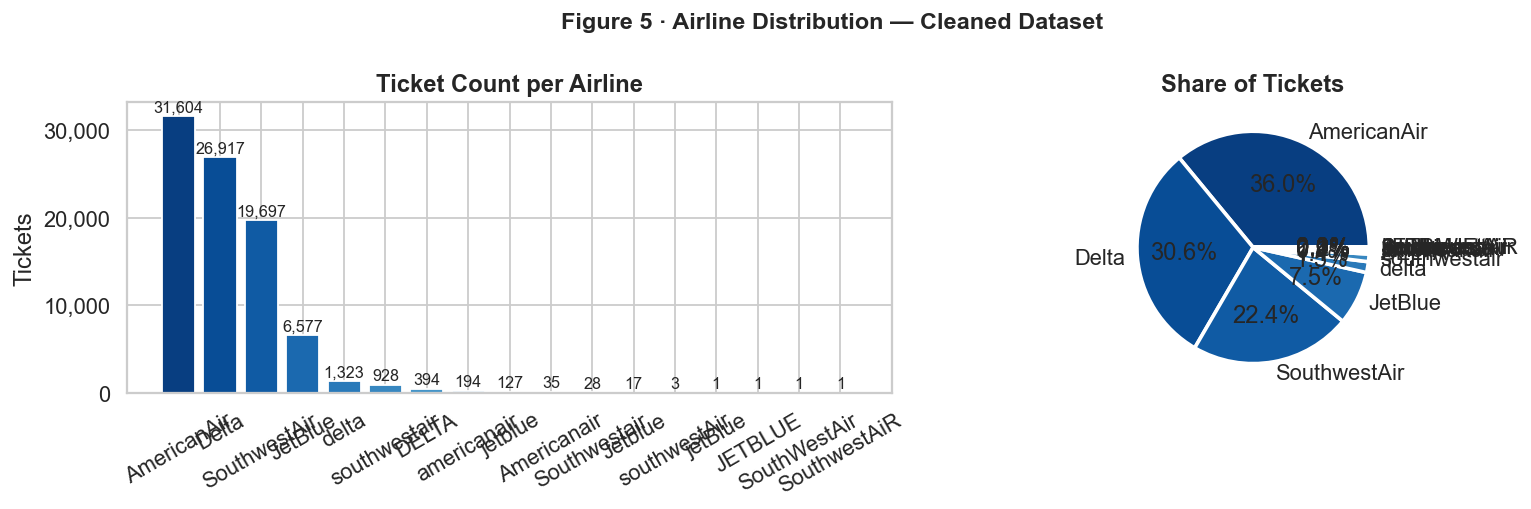

In [40]:
# Figure 5: Airline distribution in cleaned dataset
airline_counts = df_clean['airline'].value_counts()
palette = sns.color_palette('Blues_r', len(airline_counts))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bars = axes[0].bar(airline_counts.index, airline_counts.values, color=palette, edgecolor='white')
for bar, val in zip(bars, airline_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('Tickets')
axes[0].set_title('Ticket Count per Airline', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].pie(airline_counts.values, labels=airline_counts.index, autopct='%1.1f%%',
            colors=palette, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Share of Tickets', fontweight='bold')
plt.suptitle('Figure 5 · Airline Distribution — Cleaned Dataset', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


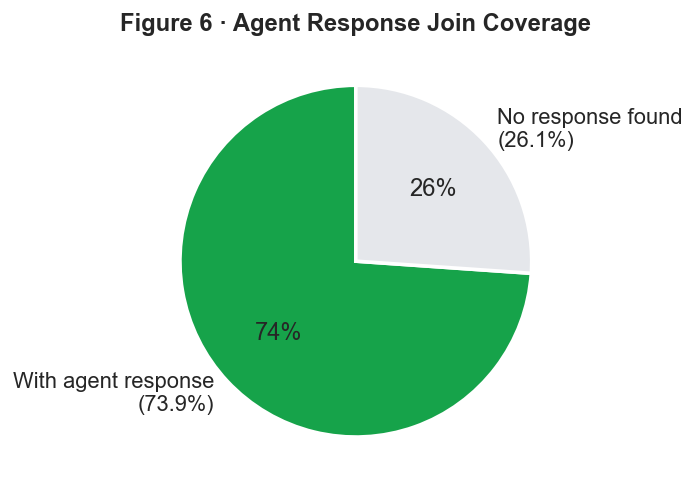

With agent response: 64,919
No response matched: 22,929

Sample ticket with response:
  Customer: i booked my flight using delta amex card. Checking in now & was being charged for baggage
  Agent:    Glad to check. Pls, DM your confirmation number for assistance. *QB


In [41]:
# Figure 6: Agent response join coverage
if 'agent_response' in df_clean.columns:
    has_resp = df_clean['agent_response'].str.len() > 0
    counts_r = [has_resp.sum(), (~has_resp).sum()]
    labels_r = [f'With agent response\n({has_resp.mean()*100:.1f}%)',
                f'No response found\n({(~has_resp).mean()*100:.1f}%)']
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.pie(counts_r, labels=labels_r, colors=['#16a34a', '#e5e7eb'],
           autopct='%1.0f%%', startangle=90,
           wedgeprops=dict(edgecolor='white', linewidth=2))
    ax.set_title('Figure 6 · Agent Response Join Coverage', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'With agent response: {has_resp.sum():,}')
    print(f'No response matched: {(~has_resp).sum():,}')
    sample = df_clean[has_resp & (df_clean['agent_response'].str.len() > 30)].iloc[0]
    print(f'\nSample ticket with response:')
    print(f'  Customer: {sample["text"]}')
    print(f'  Agent:    {sample["agent_response"][:200]}')
else:
    print('agent_response column not found in cleaned dataset')


---
## 3 · Labels — URGENT vs NORMAL (Weak Supervision)

**Labeling rule (no human annotation):**
- Hard override: critical keywords (stranded, medical, fraud…) → URGENT (score = 10)
- Additive scoring: delay signal (+3), urgency keywords (+2), profanity (+1), high caps (+1), 2+ exclamations (+1)
- Threshold: score ≥ 3 → URGENT

**Honest caveat:** the ML model learns to reproduce this rule, not real expert judgment.


In [42]:
df_labeled = pd.read_csv(paths['labeled'])
print(f'Labeled dataset: {len(df_labeled):,} rows')
print(f'Columns: {df_labeled.columns.tolist()}')
print('\nPriority distribution:')
print(df_labeled['priority'].value_counts())
print('\nScore stats:')
print(df_labeled['score'].describe().round(2))


Labeled dataset: 87,848 rows
Columns: ['tweet_id', 'customer_id', 'airline', 'created_at', 'inbound', 'original_text', 'text', 'agent_response', 'priority', 'score', 'has_critical_signal', 'has_urgency_keywords', 'has_delay', 'has_profanity', 'has_sarcasm', 'exclamation_count', 'question_count', 'caps_ratio']

Priority distribution:
priority
NORMAL    71613
URGENT    16235
Name: count, dtype: int64

Score stats:
count    87848.00
mean         1.12
std          1.91
min          0.00
25%          0.00
50%          0.00
75%          2.00
max         10.00
Name: score, dtype: float64


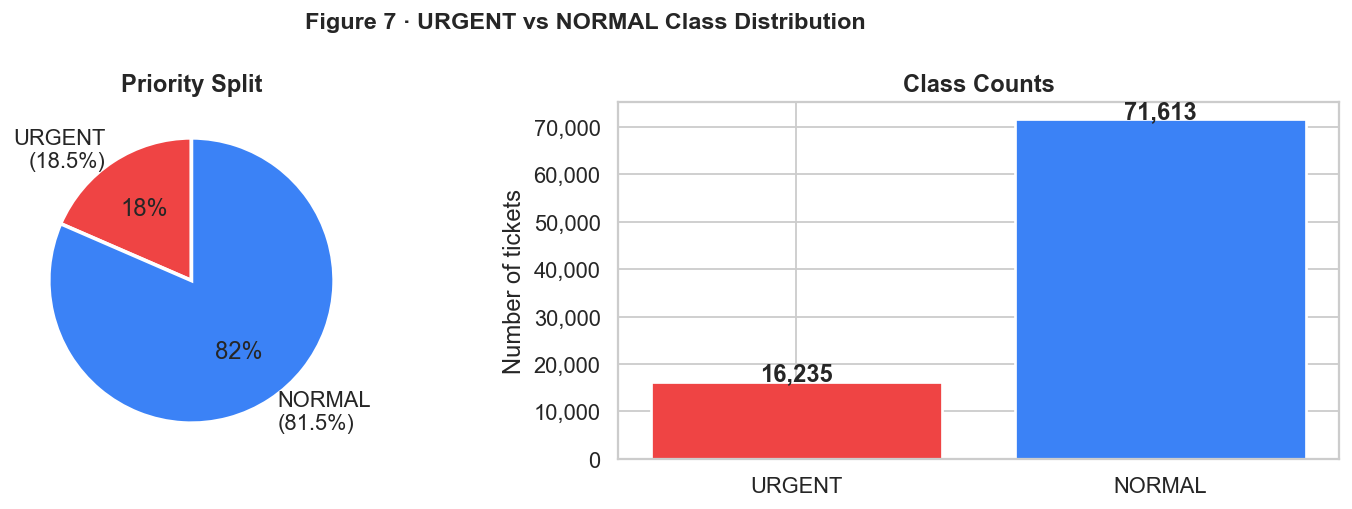

URGENT: 16,235  (18.5%)
NORMAL: 71,613  (81.5%)
Imbalance ratio: 1 URGENT for every 4.4 NORMAL tickets


In [43]:
# Figure 7: Priority distribution
prio_counts = df_labeled['priority'].value_counts()
urgent_n = prio_counts.get('URGENT', 0)
normal_n = prio_counts.get('NORMAL', 0)
total    = len(df_labeled)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(
    [urgent_n, normal_n],
    labels=[f'URGENT\n({100*urgent_n/total:.1f}%)', f'NORMAL\n({100*normal_n/total:.1f}%)'],
    colors=[URGENT_COLOR, NORMAL_COLOR], autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Priority Split', fontweight='bold')

bars = axes[1].bar(['URGENT', 'NORMAL'], [urgent_n, normal_n],
                   color=[URGENT_COLOR, NORMAL_COLOR], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, [urgent_n, normal_n]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
                 f'{val:,}', ha='center', fontweight='bold')
axes[1].set_ylabel('Number of tickets')
axes[1].set_title('Class Counts', fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.suptitle('Figure 7 · URGENT vs NORMAL Class Distribution', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
print(f'URGENT: {urgent_n:,}  ({100*urgent_n/total:.1f}%)')
print(f'NORMAL: {normal_n:,}  ({100*normal_n/total:.1f}%)')
print(f'Imbalance ratio: 1 URGENT for every {normal_n/urgent_n:.1f} NORMAL tickets')


C:\Users\LEGION\AppData\Local\Temp\ipykernel_31644\428151949.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_box, labels=['URGENT', 'NORMAL'], patch_artist=True,


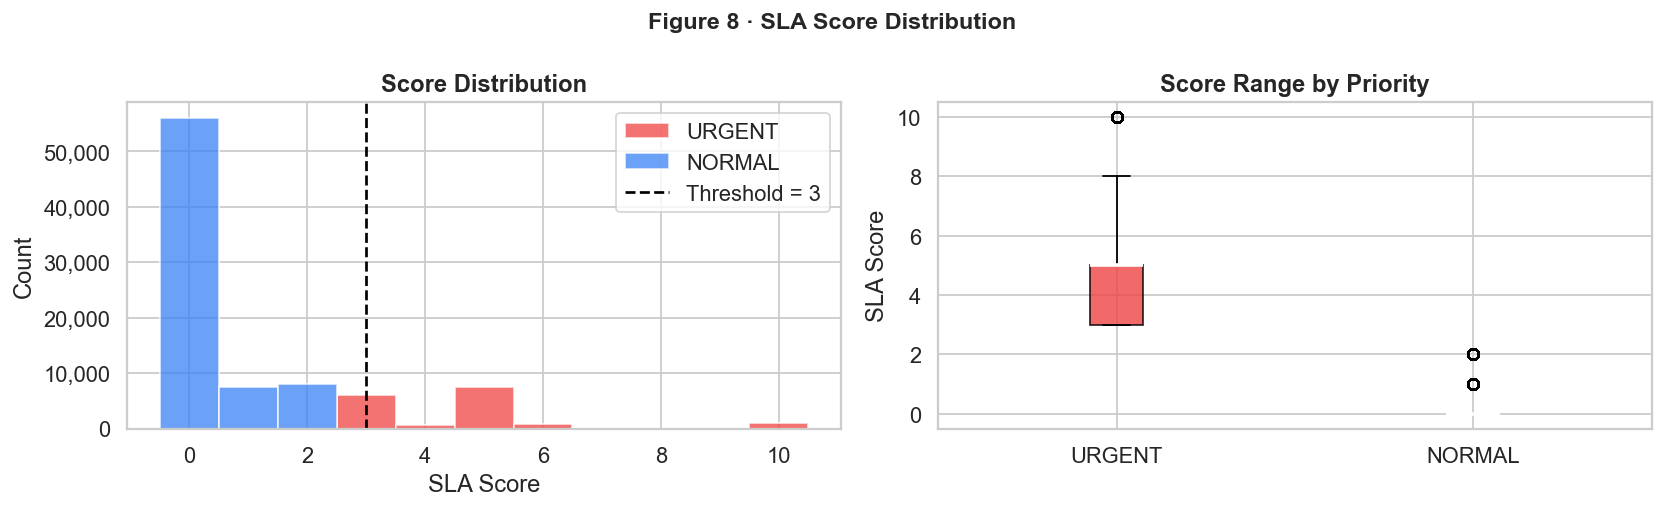

URGENT: mean=4.58  median=5  max=10
NORMAL: mean=0.33  median=0  max=2


In [44]:
# Figure 8: Score distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for priority, color in [('URGENT', URGENT_COLOR), ('NORMAL', NORMAL_COLOR)]:
    subset = df_labeled[df_labeled['priority'] == priority]['score']
    axes[0].hist(subset, bins=11, range=(-0.5, 10.5), alpha=0.75,
                 label=priority, color=color, edgecolor='white')
axes[0].axvline(3, color='black', linestyle='--', linewidth=1.5, label='Threshold = 3')
axes[0].set_xlabel('SLA Score'); axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution', fontweight='bold'); axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

data_box = [df_labeled[df_labeled['priority']=='URGENT']['score'].values,
            df_labeled[df_labeled['priority']=='NORMAL']['score'].values]
bp = axes[1].boxplot(data_box, labels=['URGENT', 'NORMAL'], patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], [URGENT_COLOR, NORMAL_COLOR]):
    patch.set_facecolor(color); patch.set_alpha(0.8)
axes[1].set_ylabel('SLA Score'); axes[1].set_title('Score Range by Priority', fontweight='bold')
plt.suptitle('Figure 8 · SLA Score Distribution', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
for p in ['URGENT', 'NORMAL']:
    s = df_labeled[df_labeled['priority']==p]['score']
    print(f'{p}: mean={s.mean():.2f}  median={s.median():.0f}  max={s.max()}')


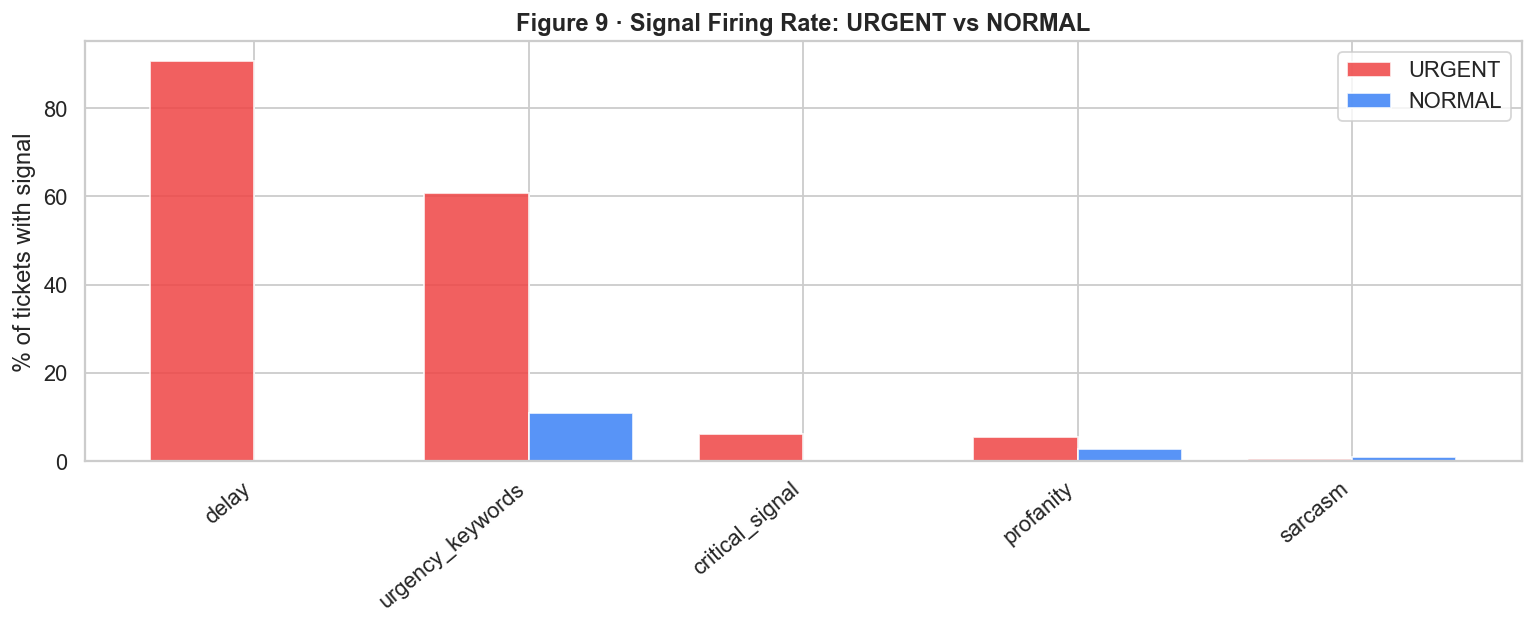

In [45]:
# Figure 9: Signal firing rates per class
bool_cols = [c for c in df_labeled.columns
             if c.startswith('has_') and
             set(df_labeled[c].dropna().unique()).issubset({0, 1, True, False})]
if not bool_cols:
    bool_cols = [c for c in ['has_critical_signal','has_urgency_keywords','has_delay',
                              'has_profanity','has_sarcasm'] if c in df_labeled.columns]

if bool_cols:
    urgent_r = df_labeled[df_labeled['priority']=='URGENT'][bool_cols].astype(float).mean()*100
    normal_r = df_labeled[df_labeled['priority']=='NORMAL'][bool_cols].astype(float).mean()*100
    sorted_idx = urgent_r.sort_values(ascending=False).index
    x = np.arange(len(sorted_idx)); w = 0.38
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x-w/2, urgent_r[sorted_idx], w, label='URGENT', color=URGENT_COLOR, alpha=0.85, edgecolor='white')
    ax.bar(x+w/2, normal_r[sorted_idx], w, label='NORMAL', color=NORMAL_COLOR, alpha=0.85, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace('has_','') for c in sorted_idx], rotation=40, ha='right')
    ax.set_ylabel('% of tickets with signal')
    ax.set_title('Figure 9 · Signal Firing Rate: URGENT vs NORMAL', fontweight='bold')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print('Signal columns not found in labeled dataset')


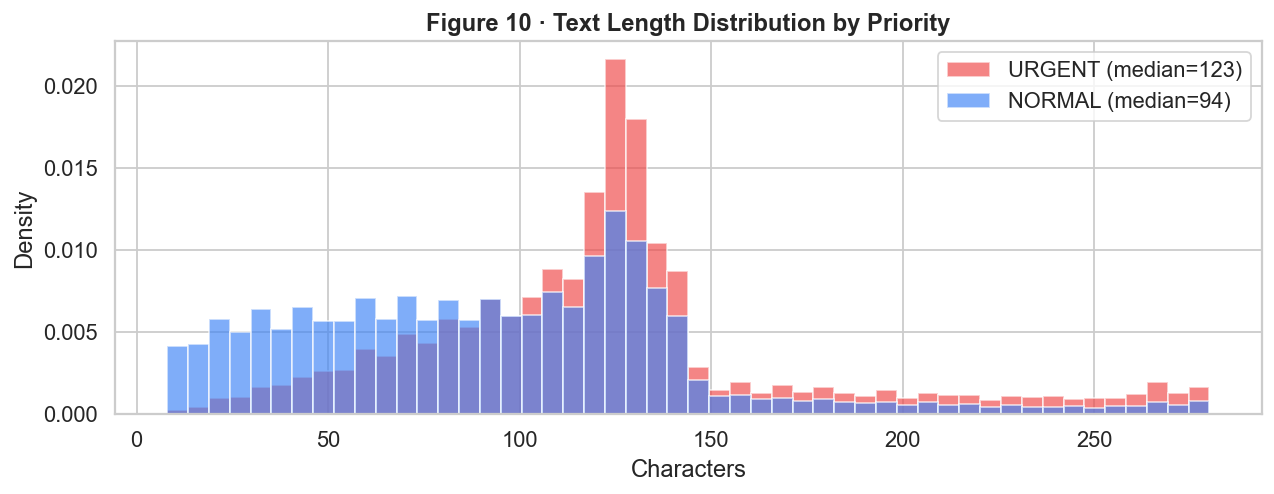

In [46]:
# Figure 10: Text length by priority
df_labeled['text_len'] = df_labeled['text'].str.len()
fig, ax = plt.subplots(figsize=(10, 4))
for priority, color in [('URGENT', URGENT_COLOR), ('NORMAL', NORMAL_COLOR)]:
    subset = df_labeled[df_labeled['priority']==priority]['text_len'].clip(upper=280)
    ax.hist(subset, bins=50, alpha=0.65, density=True, color=color, edgecolor='white',
            label=f'{priority} (median={subset.median():.0f})')
ax.set_xlabel('Characters'); ax.set_ylabel('Density')
ax.set_title('Figure 10 · Text Length Distribution by Priority', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


In [47]:
# Sample tickets
print('='*70)
print('SAMPLE URGENT TICKETS (score >= 8 — critical-level)')
print('='*70)
urgent_high = df_labeled[df_labeled['score'] >= 8][['text','score']]
for _, row in urgent_high.sample(min(5, len(urgent_high)), random_state=42).iterrows():
    print(f'[score={row["score"]}] {row["text"]}')
    print()

print('='*70)
print('SAMPLE NORMAL TICKETS (score = 0)')
print('='*70)
normal_zero = df_labeled[df_labeled['score'] == 0][['text','score']]
for _, row in normal_zero.sample(min(5, len(normal_zero)), random_state=42).iterrows():
    print(f'[score={row["score"]}] {row["text"]}')
    print()


SAMPLE URGENT TICKETS (score >= 8 — critical-level)
[score=10] Yeah and now my 8pm flight out has been canceled. This is absurd. I'm stranded in Charleston, missing a funeral and missing a biz meeting.

[score=10] Sorry to say that the handling of flights 1044 CHS-&gt;DCA And 1374 CHS-&gt;JFK have been a total disaster. Gate agents not getting info.

[score=10] our entire plane is at the gate (MLI) waiting for grounds crew! It's been 30 mins. Uh...someone needs training at MLI unacceptable!

[score=10] Yes. A different person brought it. But the first never acknowledged her question other than to roll her eyes. Very rude and unsafe.

[score=10] She REFUSED to help me. @Delta, I am aghast at this agent's treatment of me, your customer. Unacceptable.

SAMPLE NORMAL TICKETS (score = 0)
[score=0] @329789 Thank you, AAir. And speak out, please, publish public service announcements so other airlines & private pilots will listen to reason in the Trump Age of Greed and Terror.

[score=0] Why w

---
## 4 · ML Features

14 features engineered from raw text — independent of the labeling rule.
The labeler uses broad patterns; these add count-based and keyword-specific signals.


In [48]:
df_ml = pd.read_csv(paths['ml'])
print(f'ML features dataset: {len(df_ml):,} rows')
print(f'Columns: {df_ml.columns.tolist()}')
df_ml.head(3)


ML features dataset: 87,848 rows
Columns: ['tweet_id', 'airline', 'created_at', 'is_urgent', 'priority', 'score', 'has_urgency_keywords', 'has_critical_signal', 'has_profanity', 'has_sarcasm', 'text_length', 'word_count', 'exclamation_count', 'question_count', 'caps_ratio', 'has_refund', 'has_cancel', 'has_delay', 'has_help', 'has_broken', 'has_stranded', 'has_medical', 'profanity_count', 'has_time_mention']


,tweet_id,airline,created_at,is_urgent,priority,score,has_urgency_keywords,has_critical_signal,has_profanity,has_sarcasm,...,caps_ratio,has_refund,has_cancel,has_delay,has_help,has_broken,has_stranded,has_medical,profanity_count,has_time_mention
0,611,DELTA,Sat Aug 06 01:31:50 +0000 2016,0,NORMAL,0,False,False,False,False,...,0.011236,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,791,Delta,Tue Oct 31 22:33:11 +0000 2017,0,NORMAL,0,False,False,False,False,...,0.016529,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,792,Delta,Tue Oct 31 21:33:48 +0000 2017,0,NORMAL,0,False,False,False,False,...,0.016129,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [49]:
FEATURE_COLS = [
    'text_length', 'word_count', 'exclamation_count', 'question_count', 'caps_ratio',
    'has_refund', 'has_cancel', 'has_delay', 'has_help', 'has_broken',
    'has_stranded', 'has_medical', 'profanity_count', 'has_time_mention',
]
feature_cols = [c for c in FEATURE_COLS if c in df_ml.columns]
print(f'Found {len(feature_cols)} of {len(FEATURE_COLS)} expected feature columns')
df_ml[feature_cols].describe().round(3)


Found 14 of 14 expected feature columns


,text_length,word_count,exclamation_count,question_count,caps_ratio,has_refund,has_cancel,has_delay,has_help,has_broken,has_stranded,has_medical,profanity_count,has_time_mention
count,87848.000,87848.000,87848.000,87848.000,87848.000,87848.000,87848.000,87848.000,87848.000,87848.000,87848.000,87848.000,87848.000,87848.000
mean,99.649,18.560,0.380,0.358,0.047,0.011,0.029,0.066,0.053,0.005,0.003,0.001,0.032,0.055
std,52.950,9.976,0.973,0.731,0.061,0.103,0.167,0.249,0.224,0.071,0.051,0.034,0.194,0.229
min,8.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,60.000,11.000,0.000,0.000,0.019,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,101.000,18.000,0.000,0.000,0.033,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,128.000,24.000,0.000,1.000,0.057,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
max,299.000,62.000,49.000,56.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,14.000,1.000


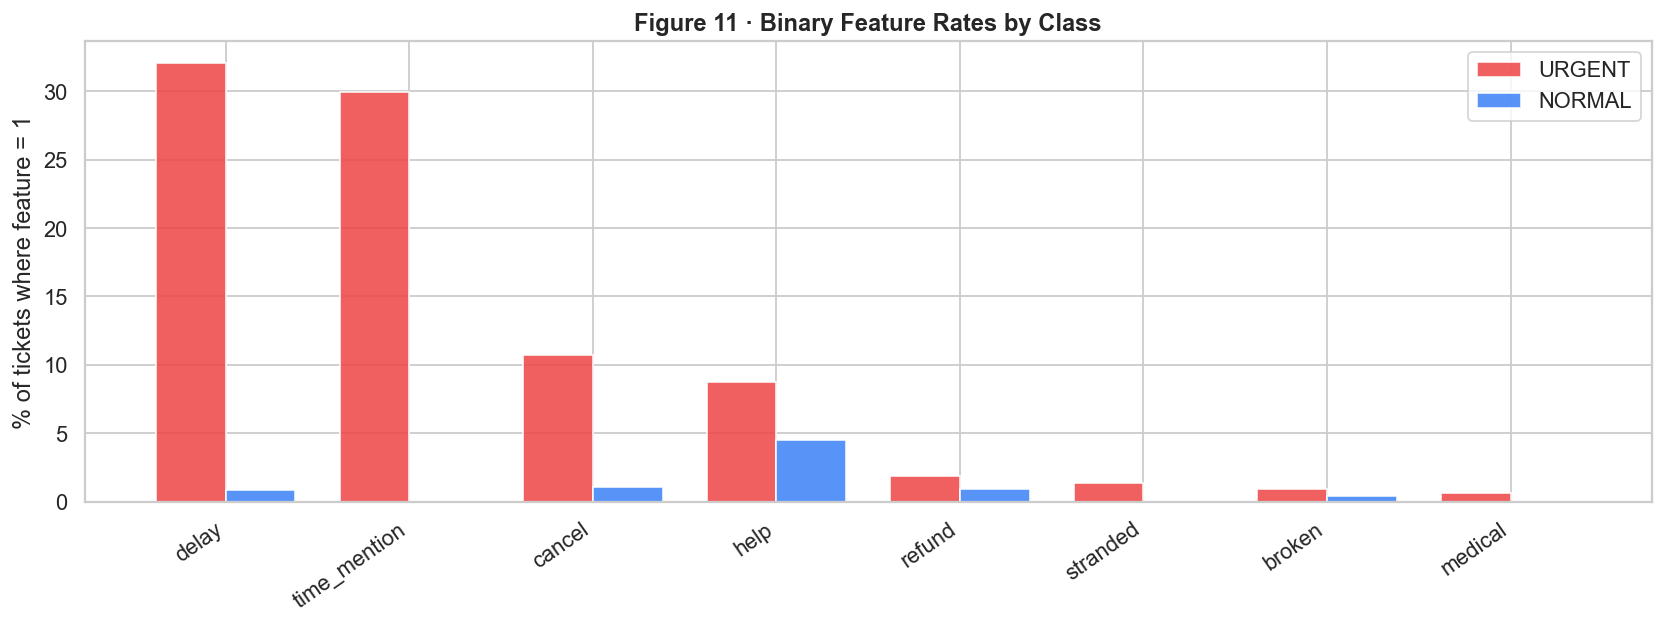

In [50]:
# Figure 11: Binary feature firing rates
binary_feats = [c for c in feature_cols if set(df_ml[c].dropna().unique()).issubset({0, 1})]
if binary_feats:
    urgent_m = df_ml[df_ml['is_urgent']==1][binary_feats].mean() * 100
    normal_m = df_ml[df_ml['is_urgent']==0][binary_feats].mean() * 100
    sorted_idx = urgent_m.sort_values(ascending=False).index
    x = np.arange(len(sorted_idx)); w = 0.38
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x-w/2, urgent_m[sorted_idx], w, label='URGENT', color=URGENT_COLOR, alpha=0.85, edgecolor='white')
    ax.bar(x+w/2, normal_m[sorted_idx], w, label='NORMAL', color=NORMAL_COLOR, alpha=0.85, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace('has_','') for c in sorted_idx], rotation=35, ha='right')
    ax.set_ylabel('% of tickets where feature = 1')
    ax.set_title('Figure 11 · Binary Feature Rates by Class', fontweight='bold')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print('No binary features found')


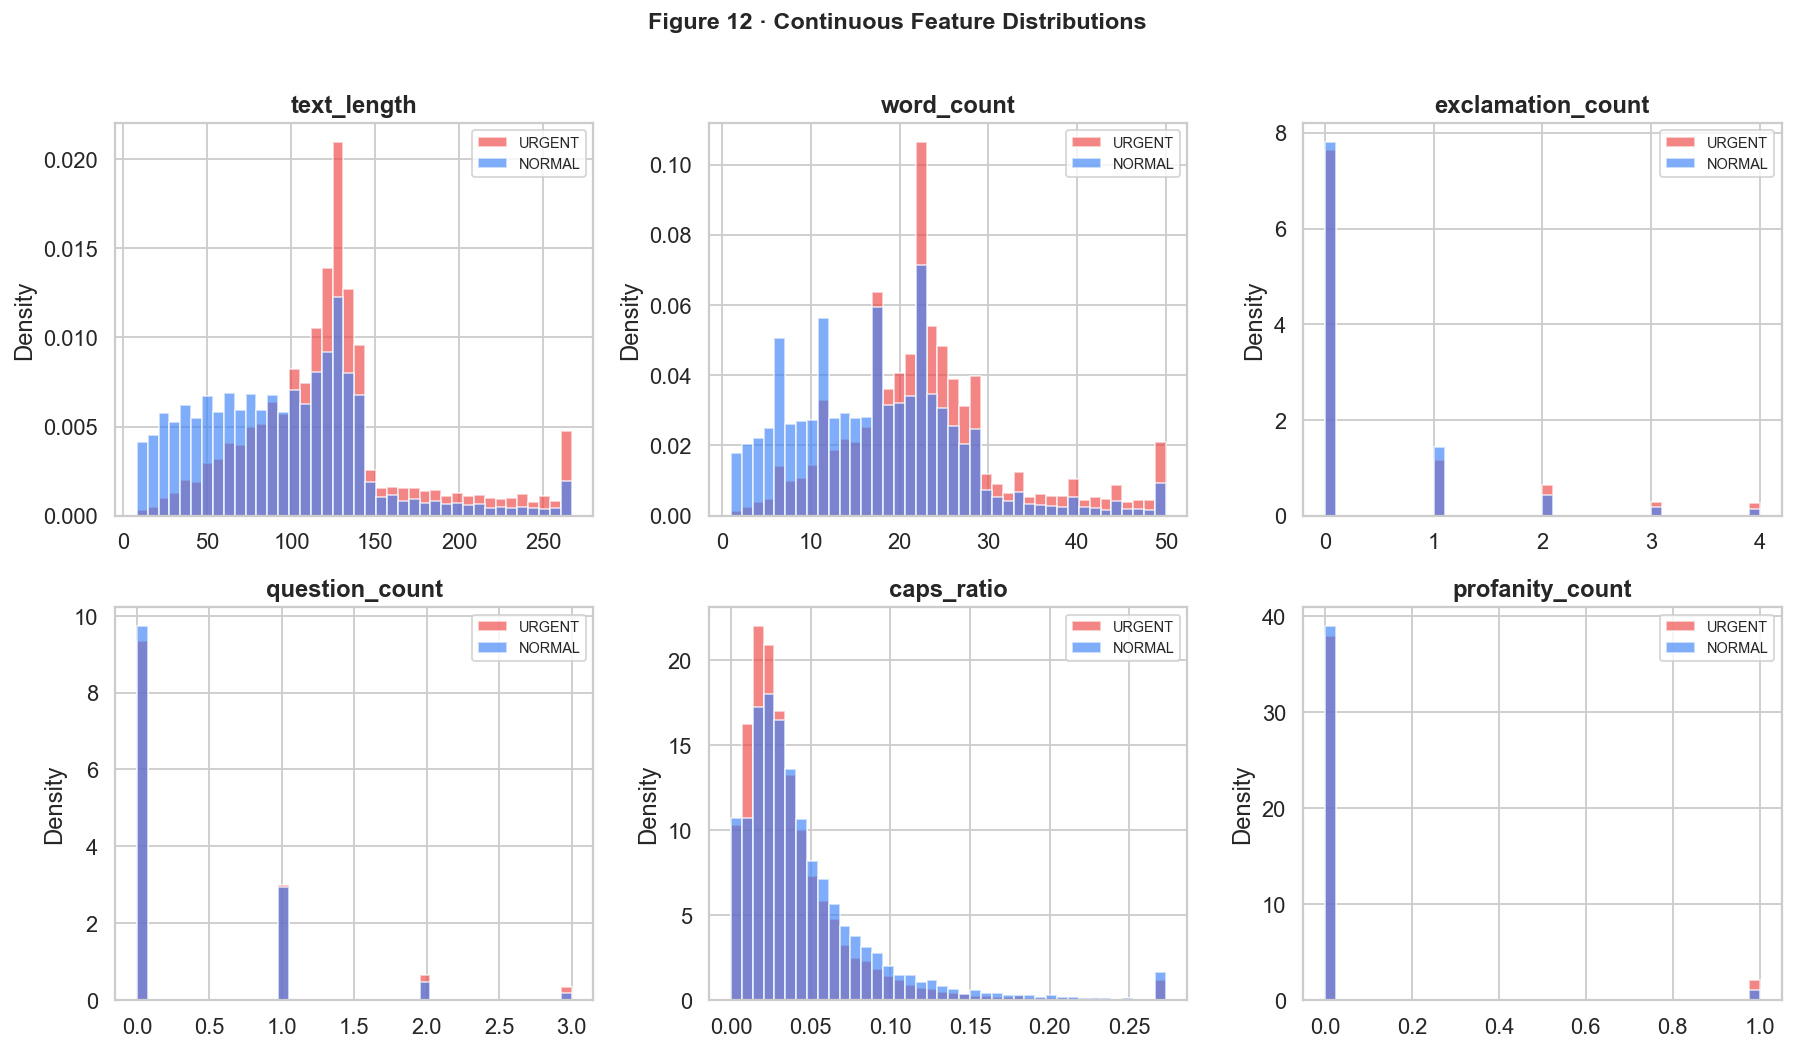

In [51]:
# Figure 12: Continuous feature distributions
cont_feats = [c for c in feature_cols if c not in binary_feats]
plot_cont  = cont_feats[:6]
if plot_cont:
    ncols = 3
    nrows = (len(plot_cont)+ncols-1)//ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
    axes = axes.flatten()
    for ax, feat in zip(axes, plot_cont):
        for label, color in [(1, URGENT_COLOR), (0, NORMAL_COLOR)]:
            vals = df_ml[df_ml['is_urgent']==label][feat].clip(upper=df_ml[feat].quantile(0.99))
            ax.hist(vals, bins=40, alpha=0.65, color=color,
                    label='URGENT' if label==1 else 'NORMAL',
                    edgecolor='white', density=True)
        ax.set_title(feat, fontweight='bold')
        ax.set_ylabel('Density'); ax.legend(fontsize=8)
    for ax in axes[len(plot_cont):]: ax.set_visible(False)
    plt.suptitle('Figure 12 · Continuous Feature Distributions', fontweight='bold', fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()


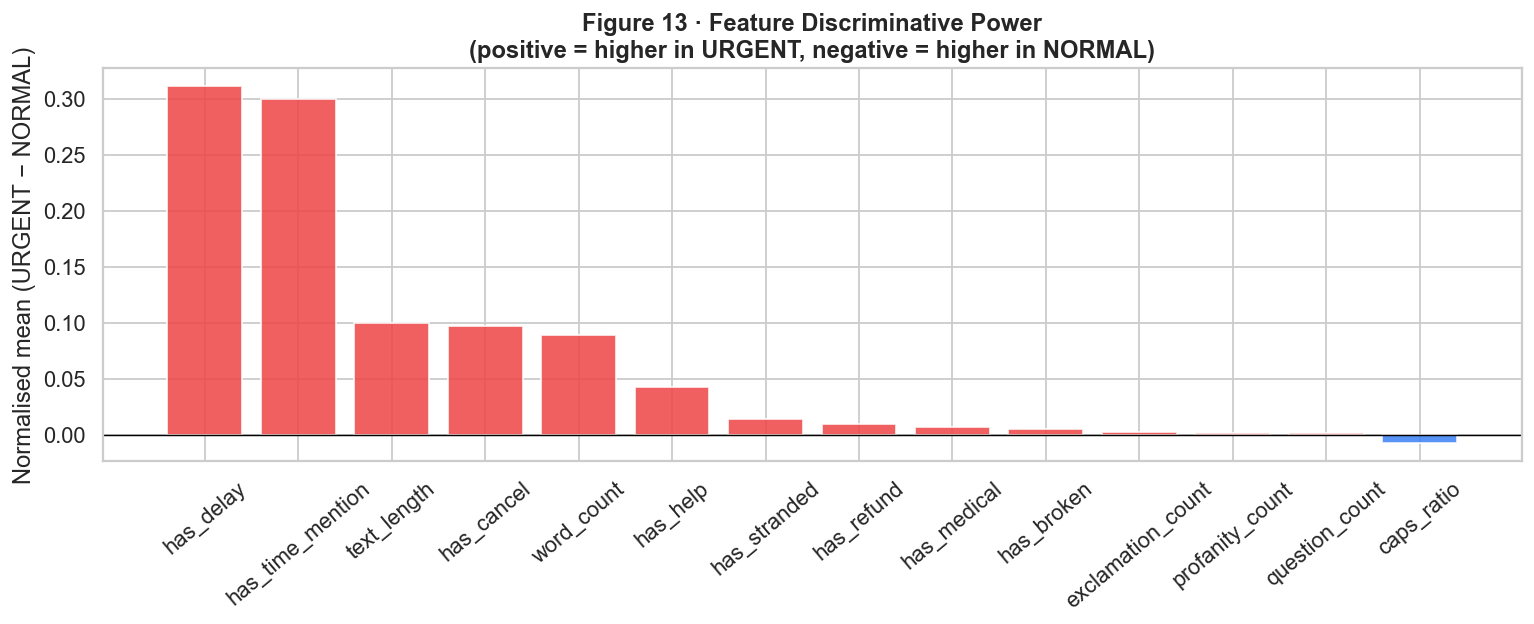

In [53]:
# Figure 13: Feature discriminative power (normalised mean difference URGENT - NORMAL)
from sklearn.preprocessing import MinMaxScaler

X = df_ml[feature_cols].fillna(0)
scaler   = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)
X_scaled['is_urgent'] = df_ml['is_urgent'].values

means = X_scaled.groupby('is_urgent')[feature_cols].mean()
diff  = (means.loc[1] - means.loc[0]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = [URGENT_COLOR if v > 0 else NORMAL_COLOR for v in diff.values]
ax.bar(diff.index, diff.values, color=bar_colors, edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Normalised mean (URGENT − NORMAL)')
ax.set_title('Figure 13 · Feature Discriminative Power\n'
             '(positive = higher in URGENT, negative = higher in NORMAL)', fontweight='bold')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout(); plt.show()


---
## 5 · Model Training Results

Three classifiers on a **60 / 20 / 20** split.
- **Validation (20%)** → used to select the best model
- **Test (20%)** → final honest report, touched exactly once

All reported metrics are from the **test set** unless noted.


In [55]:
with open(paths['metrics']) as f:
    metrics = json.load(f)

print(f"Trained at:   {metrics.get('trained_at', 'unknown')}")
print(f"Best model:   {metrics.get('best_model')}")
print(f"Dataset:      {metrics.get('dataset_size', 0):,}")
print(f"Train:        {metrics.get('train_size', 0):,}")
print(f"Validation:   {metrics.get('val_size', 0):,}")
print(f"Test:         {metrics.get('test_size', 0):,}")
print()
for name, m in metrics.get('models', {}).items():
    best_mark = '  <- BEST' if name == metrics.get('best_model') else ''
    print(f"{name:30s}  val_f1={m.get('val_f1',0):.4f}  test_f1={m.get('test_f1',0):.4f}{best_mark}")


Trained at:   2026-04-24T13:12:46.121649+00:00
Best model:   gradient_boosting
Dataset:      87,848
Train:        52,708
Validation:   17,570
Test:         17,570

logistic_regression             val_f1=0.7297  test_f1=0.7228
random_forest                   val_f1=0.7189  test_f1=0.7205
gradient_boosting               val_f1=0.7521  test_f1=0.7553  <- BEST


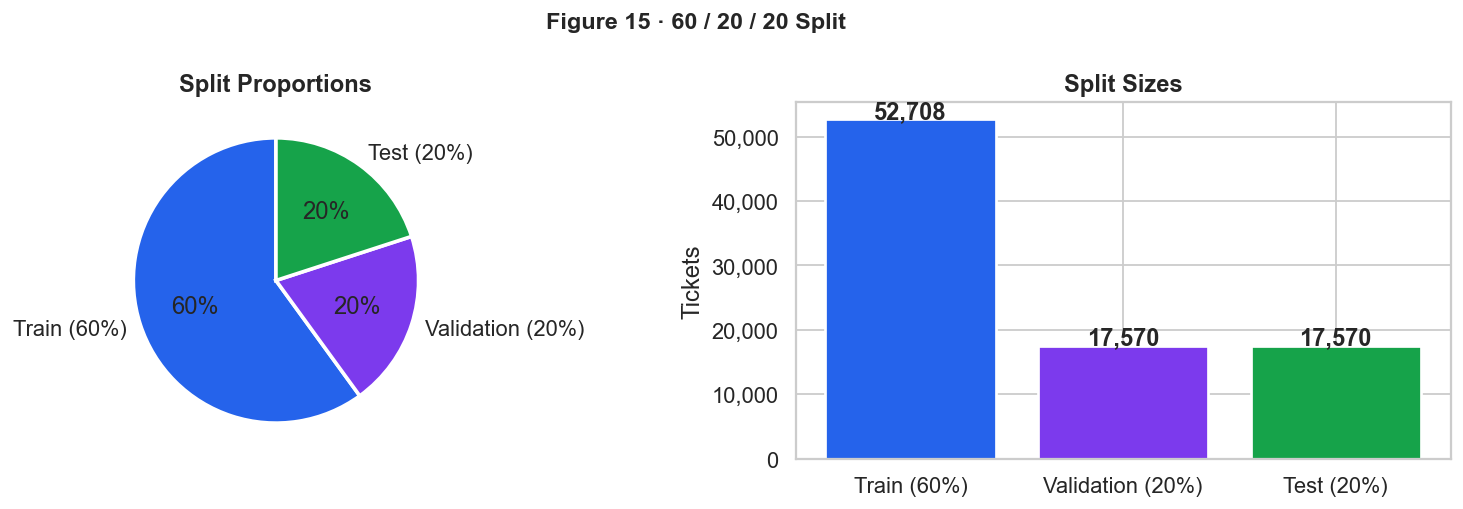

In [57]:
# Figure 15: Dataset split sizes
split_labels = ['Train (60%)', 'Validation (20%)', 'Test (20%)']
split_sizes  = [metrics.get('train_size',0), metrics.get('val_size',0), metrics.get('test_size',0)]
split_colors = ['#2563eb', '#7c3aed', '#16a34a']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(split_sizes, labels=split_labels, colors=split_colors,
            autopct='%1.0f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Split Proportions', fontweight='bold')

bars = axes[1].bar(split_labels, split_sizes, color=split_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, split_sizes):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f'{val:,}', ha='center', fontweight='bold')
axes[1].set_ylabel('Tickets')
axes[1].set_title('Split Sizes', fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.suptitle('Figure 15 · 60 / 20 / 20 Split', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


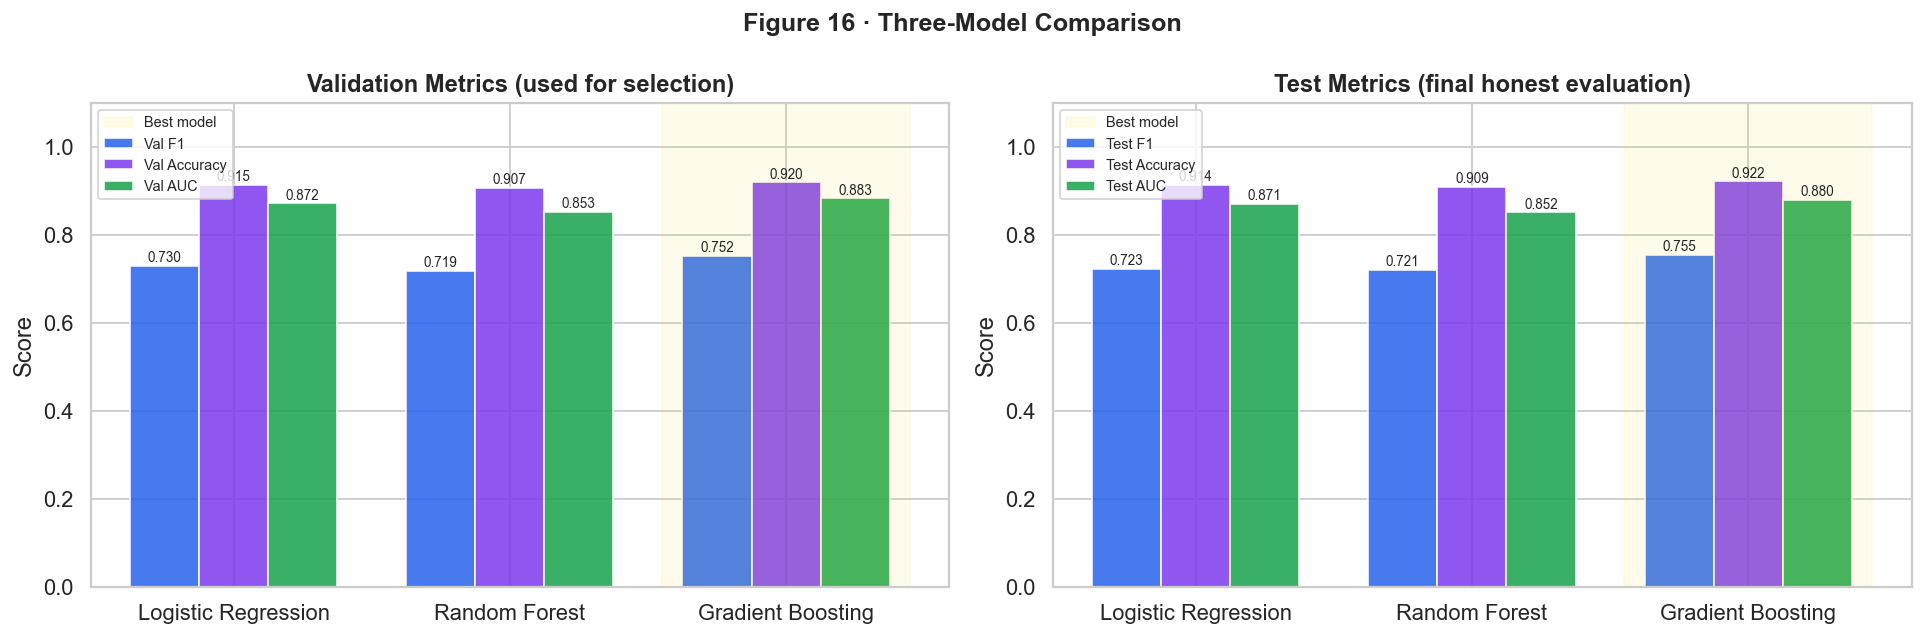

In [58]:
# Figure 16: Three-model comparison (val + test side by side)
model_names = list(metrics.get('models', {}).keys())
model_data  = metrics.get('models', {})
best_name   = metrics.get('best_model', '')
short_names = [n.replace('_', ' ').title() for n in model_names]
x = np.arange(len(model_names)); w = 0.25
best_idx = model_names.index(best_name) if best_name in model_names else -1

val_f1  = [model_data[m].get('val_f1',0)       for m in model_names]
val_acc = [model_data[m].get('val_accuracy',0)  for m in model_names]
val_auc = [model_data[m].get('val_roc_auc',0)   for m in model_names]
tst_f1  = [model_data[m].get('test_f1',0)       for m in model_names]
tst_acc = [model_data[m].get('test_accuracy',0) for m in model_names]
tst_auc = [model_data[m].get('test_roc_auc',0)  for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, mv, mn, title in [
    (axes[0], [val_f1, val_acc, val_auc], ['Val F1','Val Accuracy','Val AUC'],
     'Validation Metrics (used for selection)'),
    (axes[1], [tst_f1, tst_acc, tst_auc], ['Test F1','Test Accuracy','Test AUC'],
     'Test Metrics (final honest evaluation)'),
]:
    for i, (vals, label, color) in enumerate(zip(mv, mn, ['#2563eb','#7c3aed','#16a34a'])):
        bars = ax.bar(x+(i-1)*w, vals, w, label=label, color=color, alpha=0.85, edgecolor='white')
        for bi, bar in enumerate(bars):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                    f'{vals[bi]:.3f}', ha='center', va='bottom', fontsize=7.5)
    if best_idx >= 0:
        ax.axvspan(best_idx-0.45, best_idx+0.45, alpha=0.08, color='gold', label='Best model')
    ax.set_xticks(x); ax.set_xticklabels(short_names)
    ax.set_ylim(0, 1.10); ax.set_ylabel('Score')
    ax.set_title(title, fontweight='bold'); ax.legend(fontsize=8)
plt.suptitle('Figure 16 · Three-Model Comparison', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()


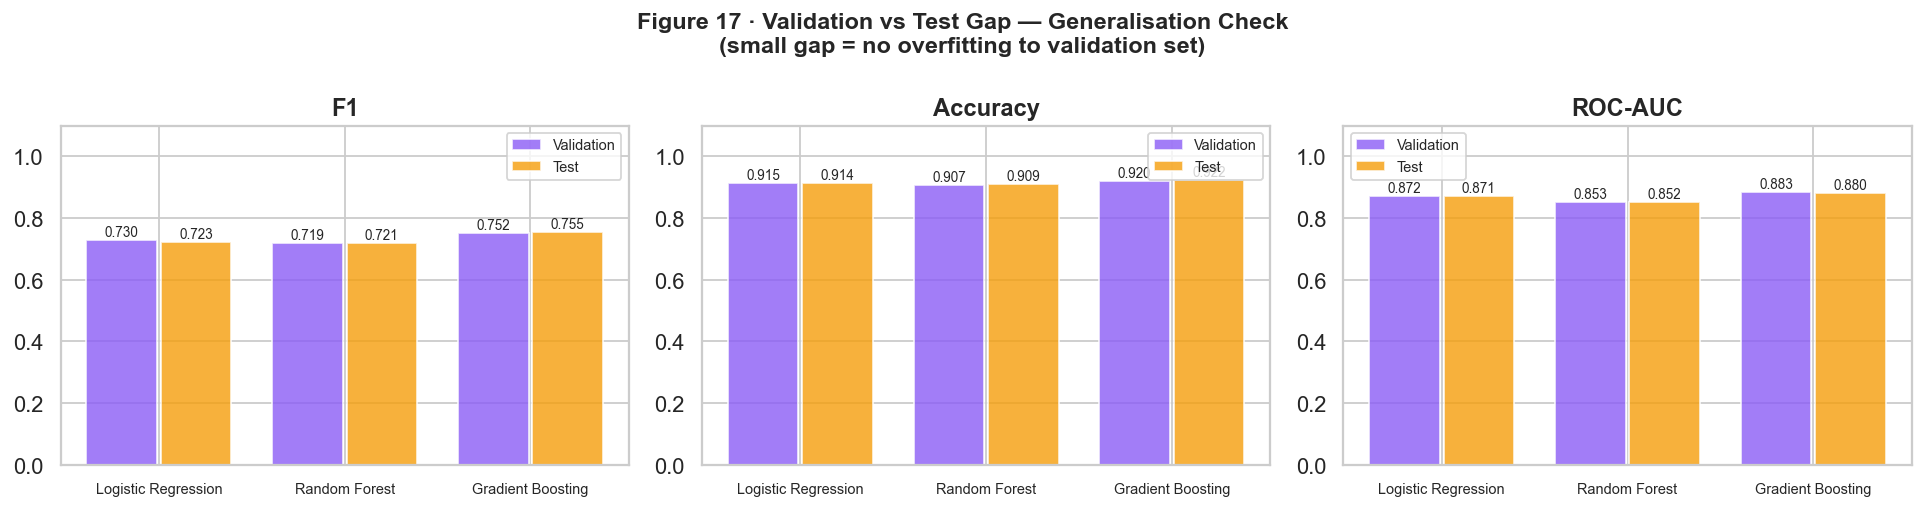

Val -> Test F1 change:
  logistic_regression             0.7297 -> 0.7228  (delta=-0.0069)
  random_forest                   0.7189 -> 0.7205  (delta=+0.0016)
  gradient_boosting               0.7521 -> 0.7553  (delta=+0.0032)


In [59]:
# Figure 17: Val vs Test gap — generalisation check
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (mname, vk, tk) in zip(axes, [
    ('F1',       'val_f1',       'test_f1'),
    ('Accuracy', 'val_accuracy', 'test_accuracy'),
    ('ROC-AUC',  'val_roc_auc',  'test_roc_auc'),
]):
    val_vals = [model_data[m].get(vk, 0) for m in model_names]
    tst_vals = [model_data[m].get(tk, 0) for m in model_names]
    xi = np.arange(len(model_names))
    ax.bar(xi-0.2, val_vals, 0.38, label='Validation', color=ACCENT_COLOR, alpha=0.8, edgecolor='white')
    ax.bar(xi+0.2, tst_vals, 0.38, label='Test',       color='#f59e0b',    alpha=0.8, edgecolor='white')
    for i, (v, t) in enumerate(zip(val_vals, tst_vals)):
        ax.text(i-0.2, v+0.003, f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)
        ax.text(i+0.2, t+0.003, f'{t:.3f}', ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(xi)
    ax.set_xticklabels([n.replace('_',' ').title() for n in model_names], fontsize=8)
    ax.set_ylim(0, 1.10); ax.set_title(mname, fontweight='bold'); ax.legend(fontsize=8)
plt.suptitle('Figure 17 · Validation vs Test Gap — Generalisation Check\n'
             '(small gap = no overfitting to validation set)', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

print('Val -> Test F1 change:')
for m in model_names:
    v = model_data[m].get('val_f1', 0)
    t = model_data[m].get('test_f1', 0)
    print(f'  {m:30s}  {v:.4f} -> {t:.4f}  (delta={t-v:+.4f})')


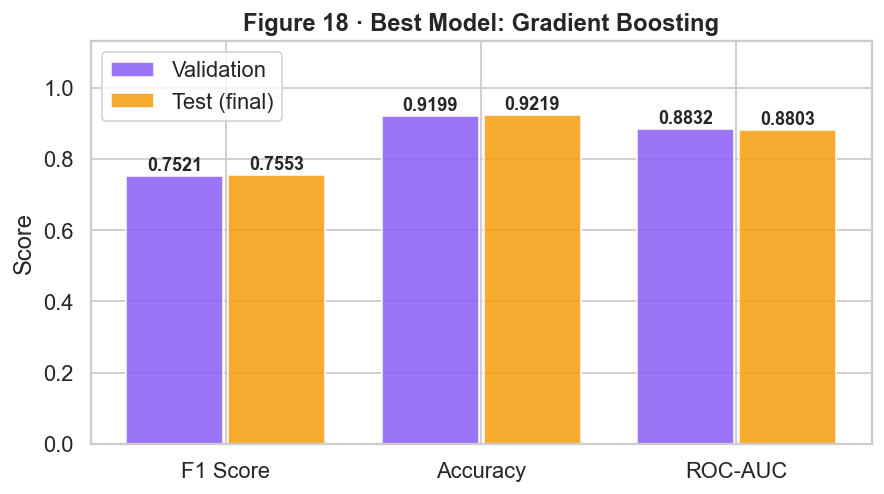

WINNER: GRADIENT BOOSTING
  Selected by: highest validation F1
  Test F1:     0.7553
  Test Acc:    0.9219
  Test AUC:    0.8803


In [60]:
best_m = model_data.get(best_name, {})
metric_labels = ['F1 Score', 'Accuracy', 'ROC-AUC']
val_scores  = [best_m.get('val_f1',0), best_m.get('val_accuracy',0), best_m.get('val_roc_auc',0)]
test_scores = [best_m.get('test_f1',0), best_m.get('test_accuracy',0), best_m.get('test_roc_auc',0)]

fig, ax = plt.subplots(figsize=(7, 4))
xi = np.arange(3)
ax.bar(xi-0.2, val_scores,  0.38, label='Validation',  color=ACCENT_COLOR, alpha=0.85, edgecolor='white')
ax.bar(xi+0.2, test_scores, 0.38, label='Test (final)', color='#f59e0b',    alpha=0.85, edgecolor='white')
for i, (v, t) in enumerate(zip(val_scores, test_scores)):
    ax.text(i-0.2, v+0.005,  f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.text(i+0.2, t+0.005, f'{t:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_xticks(xi); ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.13); ax.set_ylabel('Score')
ax.set_title(f'Figure 18 · Best Model: {best_name.replace("_"," ").title()}', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

print(f'{"="*50}')
print(f'WINNER: {best_name.replace("_"," ").upper()}')
print(f'  Selected by: highest validation F1')
print(f'  Test F1:     {best_m.get("test_f1", 0):.4f}')
print(f'  Test Acc:    {best_m.get("test_accuracy", 0):.4f}')
print(f'  Test AUC:    {best_m.get("test_roc_auc", 0):.4f}')
print(f'{"="*50}')


---
## Summary

| Stage | Count | Notes |
|---|---|---|
| Raw TWCS CSV | ~2,811,774 | All tweets, inbound + outbound |
| Inbound only | ~1,382,038 | Customer-to-brand messages |
| After airline filter | ~91,744 | 6 target airlines |
| Final clean dataset | ~87,848 | After quality filtering |
| With agent response | ~64,919 (73.9%) | RAG-enriched tickets |
| URGENT tickets | ~16,235 (18.5%) | Weak supervision label |
| NORMAL tickets | ~71,613 (81.5%) | |

**Key insight:** The class imbalance (18.5% URGENT) is why **F1** is the primary selection metric —
a model that always predicts NORMAL scores ~81.5% accuracy while being completely useless.

**Honest caveat:** All labels were generated by a keyword-scoring rule, not human annotators.
The ML model learns to reproduce that rule consistently at scale, not real expert triage judgment.
